In [1]:
# on Colab / fresh environments, uncomment:
# %pip install -U storywrangler

In [2]:
# local packages
from storywrangler import Storywrangler
from py_allotax import allotaxonograph

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
import storywrangler
print(storywrangler.__version__)

0.0.10


In [4]:
client=Storywrangler()

## Exploring datasets

In [5]:
r = client.registry

In [6]:
# displaying a client shows what its route serves — here, the catalog itself
r

Registry — 18 datasets:
  babynames/ngrams                     latest   Baby names by popularity, year, and location with entity ...
  open-academic-analytics/academic-research-groups latest   UVM faculty roster with OpenAlex IDs, departments, and re...
  open-academic-analytics/authors      latest   Per-author summary: current career age, last publication ...
  open-academic-analytics/coauthors    latest   UVM faculty coauthor relationships with age categories an...
  open-academic-analytics/papers       latest   UVM faculty papers with UMAP embeddings, citation metrics...
  open-academic-analytics/training     latest   UVM faculty collaboration training data in wide format wi...
  reddit/ngrams                        latest   Reddit ngrams
  scisciDB/field-topic-metrics         latest   Precomputed paper counts by S2 field of study, OpenAlex p...
  scisciDB/field-venue-metrics         latest   Precomputed paper counts by S2 field of study, venue, yea...
  twitter/ngrams              

In [7]:
# when applicable, dataframe is callable
r.list().df().head()

,catalog,domain,dataset_id,version,data_location,data_format,description,endpoint_schema,level_order,filter_values,created_at,updated_at
0,vcsi,babynames,ngrams,latest,[/users/j/s/jstonge1/babynames/metadata.duckla...,parquet,"Baby names by popularity, year, and location w...","{'type': 'types-counts', 'type_column': None, ...",None,"{'sex': ['F', 'M']}",2026-04-07T16:35:14.417279+00:00,2026-07-17T15:03:23.490632+00:00
1,vcsi,open-academic-analytics,academic-research-groups,latest,/users/j/s/jstonge1/academic-research-groups/a...,parquet,"UVM faculty roster with OpenAlex IDs, departme...",None,None,None,2026-04-07T16:50:31.443578+00:00,2026-04-20T17:47:35.246812+00:00
2,vcsi,open-academic-analytics,authors,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,"Per-author summary: current career age, last p...",None,None,None,2026-04-07T16:47:46.316179+00:00,2026-04-07T16:47:46.320173+00:00
3,vcsi,open-academic-analytics,coauthors,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,UVM faculty coauthor relationships with age ca...,None,None,None,2026-04-07T16:47:46.299656+00:00,2026-04-07T16:47:46.305212+00:00
4,vcsi,open-academic-analytics,papers,latest,/netfiles/compethicslab/open-academic-analytic...,parquet,"UVM faculty papers with UMAP embeddings, citat...",None,None,None,2026-04-07T16:47:46.289511+00:00,2026-04-07T16:47:46.295242+00:00


- the `sdk` matches the [api-reference](https://storywrangler.uvm.edu/api-reference), e.g. [https://api.storywrangler.uvm.edu/registry/](https://storywrangler.uvm.edu/api-reference/registry/) -> `client.registry.list()`.
- you get the metadata for each dataset; see [here](https://storywrangler.uvm.edu/api-reference/registry/post-registry-register) for description of all the fields (also we maintain [storywrangler specification](https://storywrangler.uvm.edu/specification#37-dataset-registration-schema), an open source specs to discuss the schema).

## Deep dive `babynames` dataset

In [8]:
# create a dataset object
bb = client.dataset("babynames", "ngrams")
# raw metadata also works: client.registry.get("babynames", "ngrams")

In [9]:
# looking up registered transforms
bb.meta['transform']

{'time_dimension': 'year',
 'filter_dimensions': ['sex'],
 'time_partitions': None,
 'hash_bucket': None,
 'hash_algorithm': 'murmur3_32',
 'hash_seed': 0}

In [10]:
# the ergonomic view: every filter dimension with defaults and valid values
bb.filters

{'sex': {'default': None, 'valid': ['F', 'M']}}

In [11]:
# lookuping filter values
bb.meta['filter_values']['sex']

['F', 'M']

In [12]:
# the manifest, or what metadata is available per country
bb.availability

{'quebec': {'min': '1980', 'max': '2024', 'types': 1700},
 'united_states': {'min': '1880', 'max': '2024', 'types': 29225}}

In [13]:
# entity -> entity local_id
bb.adapter

[{'local_id': 'united_states',
  'entity_id': 'wikidata:Q30',
  'entity_name': 'United States',
  'entity_ids': ['iso:US', 'local:babynames:united_states']},
 {'local_id': 'quebec',
  'entity_id': 'wikidata:Q176',
  'entity_name': 'Quebec',
  'entity_ids': ['iso:CA-QC', 'local:babynames:quebec']}]

In [14]:
# same mapping as a table
bb.adapter.df()

,local_id,entity_id,entity_name,entity_ids
0,united_states,wikidata:Q30,United States,"[iso:US, local:babynames:united_states]"
1,quebec,wikidata:Q176,Quebec,"[iso:CA-QC, local:babynames:quebec]"


In [15]:
# top names for two systems at once; limit uses the vocabulary ceiling from availability
ngram_data = bb.top_ngrams(
    entity="wikidata:Q30",
    dates=1968, dates2=2018,
    sex="M", limit=bb.availability["united_states"]["types"],
)
list(ngram_data)

['1968', '2018', 'metadata']

In [16]:
df1=pd.DataFrame(ngram_data['1968'])
df2=pd.DataFrame(ngram_data['2018'])

In [17]:
# all ngrams data are in the standards "types-count" format
df1.head()

,types,counts
0,Michael,81974.0
1,David,63683.0
2,John,60906.0
3,James,60666.0
4,Robert,58186.0


In [18]:
# or as one table — .df() concatenates the two systems with a label column
bb.top_ngrams(entity="wikidata:Q30", dates=1968, dates2=2018, sex="M", limit=3).df()

,types,counts,system
0,Michael,81974.0,1968
1,David,63683.0,1968
2,John,60906.0,1968
3,Liam,19974.0,2018
4,Noah,18429.0,2018
5,William,14645.0,2018


## Wikimedia

In [19]:
wiki = client.dataset("wikimedia", "ngrams")
wiki.endpoints

{'/wikimedia/top-ngrams': {'summary': 'Get Top Ngrams', 'dataset': 'ngrams'},
 '/wikimedia/revisions': {'summary': 'List Revision Articles',
  'dataset': 'revisions'},
 '/wikimedia/revisions/{identifier}': {'summary': 'Get Revision Deltas',
  'dataset': 'revisions'},
 '/wikimedia/term-series': {'summary': 'Term Series', 'dataset': 'ngrams'},
 '/wikimedia/term-series/batch': {'summary': 'Term Series Batch',
  'dataset': 'ngrams'},
 '/wikimedia/precomputed-rtd': {'summary': 'Precomputed Rtd',
  'dataset': 'precomputed_rtd'},
 '/wikimedia/semantic-timeseries': {'summary': 'Semantic Timeseries',
  'dataset': 'semantic-timeseries'},
 '/wikimedia/semantic-ngrams': {'summary': 'Semantic Ngrams',
  'dataset': 'semantic-ngrams'}}

In [20]:
ts1 = wiki.term_series("Trump", entity="wikidata:Q30", window=365).df().set_index("date").assign(name=lambda x: "Trump")[['rank', 'name']]
ts2 = wiki.term_series("Harris", entity="wikidata:Q30", window=365).df().set_index("date").assign(name=lambda x: "Harris")[['rank', 'name']]

In [21]:
ts_df=pd.merge(ts1, ts2, on="date", suffixes=[" Trump", " Harris"])

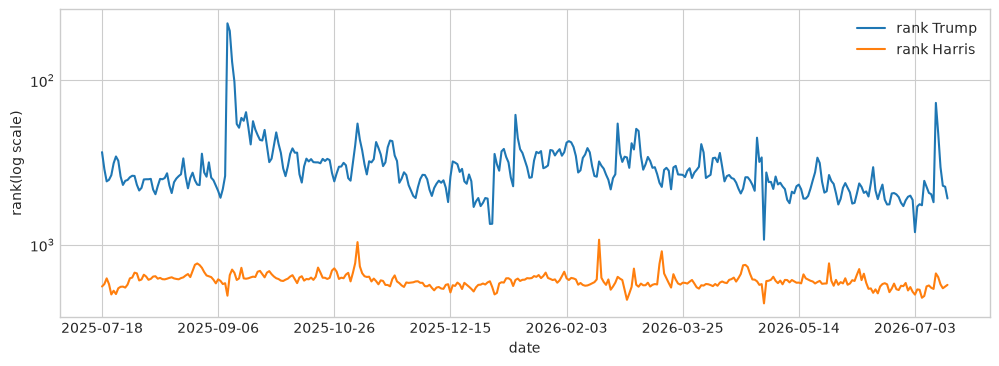

In [22]:
ax=ts_df.plot(logy=True, figsize=(12,4));
plt.gca().invert_yaxis()
ax.set_ylabel("rank(log scale)");

- easy to customize plot using `pandas` and `matplotlib` combo.

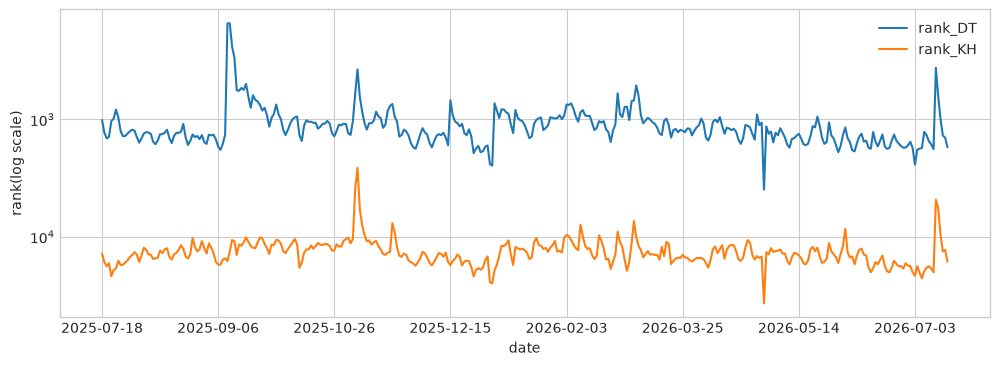

In [23]:
#bigrams analysis
tsb1 = wiki.term_series("Donald Trump", entity="wikidata:Q30", ngram_size=2, window=365).df().set_index("date").assign(name=lambda x: "Donald Trump")[['rank', 'name']]
tsb2 = wiki.term_series("Kamala Harris", entity="wikidata:Q30", ngram_size=2, window=365).df().set_index("date").assign(name=lambda x: "Kamala Harris")[['rank', 'name']]
tsb_df=pd.merge(tsb1, tsb2, on="date", suffixes=["_DT", "_KH"])

ax=tsb_df.plot(logy=True, figsize=(12,4));
plt.gca().invert_yaxis()
ax.set_ylabel("rank(log scale)");


In [24]:
# batch: several terms in one request — long format with a `type` column
wiki.term_series_batch(["Trump", "Harris"], entity="wikidata:Q30", window=30,
                       include_articles=False).df().head()

,date,counts,rank,freq,type
0,2026-06-18,43349132,472,0.000194,Trump
1,2026-06-19,47306189,430,0.000211,Trump
2,2026-06-20,38342134,531,0.000171,Trump
3,2026-06-21,39356641,568,0.000160,Trump
4,2026-06-22,42927942,567,0.000158,Trump


In [25]:
#bigrams analysis
tsb_sb_us = wiki.term_series("Super Bowl", entity="United States", ngram_size=2, window=999).df().assign(name=lambda x: "US")[['rank', 'name', 'date']]
tsb_wc_us = wiki.term_series("Fifa World", entity="United States", ngram_size=2, window=999).df().assign(name=lambda x: "US")[['rank', 'name', 'date']]

tsb_sb_uk = wiki.term_series("Super Bowl", entity="United Kingdom", ngram_size=2, window=999).df().assign(name=lambda x: "UK")[['rank', 'name', 'date']]
tsb_wc_uk = wiki.term_series("Fifa World", entity="United Kingdom", ngram_size=2, window=999).df().assign(name=lambda x: "UK")[['rank', 'name', 'date']]

datetime64[us] 656
datetime64[us] 656


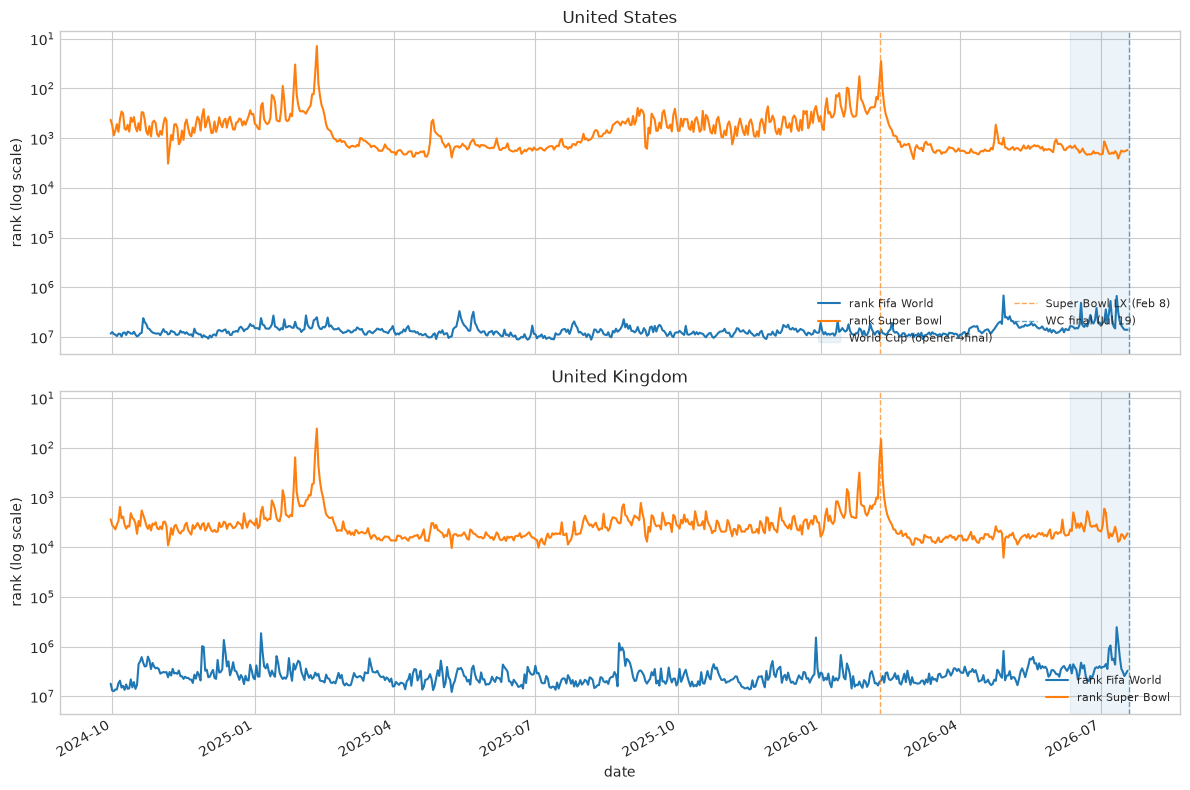

In [26]:
# --- normalize the join key first (this is what fixes the vline offset) ---
for df in (tsb_wc_us, tsb_sb_us, tsb_wc_uk, tsb_sb_uk):
    df["date"] = pd.to_datetime(df["date"])

# --- data ---
tsb_us_df = (pd.merge(tsb_wc_us, tsb_sb_us, on="date",
                      suffixes=[" Fifa World", " Super Bowl"])
               .set_index("date").sort_index())

tsb_uk_df = (pd.merge(tsb_wc_uk, tsb_sb_uk, on="date",
                      suffixes=[" Fifa World", " Super Bowl"])
               .set_index("date").sort_index())

print(tsb_us_df.index.dtype, len(tsb_us_df))   # expect datetime64[ns]
print(tsb_uk_df.index.dtype, len(tsb_uk_df))

# --- events ---
SB_LX     = pd.Timestamp("2026-02-08")   # Super Bowl LX, Levi's Stadium
WC_OPENER = pd.Timestamp("2026-06-11")   # World Cup opening match
WC_FINAL  = pd.Timestamp("2026-07-19")   # World Cup final, MetLife

# --- plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

tsb_us_df.plot(logy=True, ax=ax1)
tsb_uk_df.plot(logy=True, ax=ax2)

for ax in (ax1, ax2):
    first = ax is ax1  # label once so the legend isn't duplicated
    ax.axvspan(WC_OPENER, WC_FINAL, color="tab:blue", alpha=0.08,
               label="World Cup (opener→final)" if first else None)
    ax.axvline(SB_LX, color="tab:orange", ls="--", lw=1, alpha=0.7,
               label="Super Bowl LX (Feb 8)" if first else None)
    ax.axvline(WC_FINAL, color="tab:blue", ls="--", lw=1, alpha=0.7,
               label="WC final (Jul 19)" if first else None)
    ax.set_ylabel("rank (log scale)")

ax1.set_title("United States")
ax2.set_title("United Kingdom")
ax2.set_xlabel("date")

ax1.invert_yaxis()          # sharey=True → flips both
ax1.legend(loc="lower right", fontsize=8, ncol=2)
ax2.legend(loc="lower right", fontsize=8)

fig.tight_layout()
plt.show()

## Domain objects & dynamic routes

In [27]:
# one-argument scoping works when a domain has a single dataset;
# displaying it lists the endpoints (mirrors GET /{domain})
tw = client.dataset("twitter")
tw

Domain 'twitter' — endpoints:
  /twitter/term-series                         Term Series  [serves: ngrams]
  /twitter/term-series/batch                   Term Series Batch  [serves: ngrams]
  /twitter/top-ngrams                          Top Ngrams  [serves: ngrams]
datasets: ['ngrams'] — client.dataset('twitter', <id>) for metadata

In [28]:
# multi-dataset domains ask you to choose — errors carry the fix
try:
    client.dataset("wikimedia").availability
except ValueError as e:
    print(e)

This is dataset-specific and domain 'wikimedia' has 7 registered datasets — use client.dataset('wikimedia', <id>) with id in ['ngrams', 'precomputed_rtd', 'revisions', 'semantic-ngrams', 'semantic-timeseries', 'sparklines', 'top_articles_ngrams'].


In [29]:
# any route is callable by its guessable name (underscores map to dashes)
wiki.revisions(limit=2)["articles"]

[{'identifier': 81858235,
  'name': 'Deaths in 2026',
  'revision_count': 3481,
  'first_edit': '2026-01-02T16:18:43Z',
  'last_edit': '2026-03-06T23:46:27Z'},
 {'identifier': 82533582,
  'name': '2026 Israeli–United States strikes on Iran',
  'revision_count': 3071,
  'first_edit': '2026-02-28T06:24:01Z',
  'last_edit': '2026-03-07T00:00:43Z'}]

## The escape hatch & platform status

In [30]:
# routes without a dedicated method are one .get() away
client.get("/open-academic-analytics/authors")[:1]

[{'ego_display_name': 'Abigail Crocker',
  'current_age': 20,
  'last_pub_year': 2024,
  'has_research_group': False}]

In [31]:
# component versions and dataset health
client.version(), client.health.status()["summary"]

({'api': '1.0.0', 'schemas': '0.2.0', 'duckdb': '1.5.0', 'allotax': '0.3.2'},
 {'total': 21, 'healthy': 20, 'degraded': 0, 'unhealthy': 1})